In [1]:
import yfinance as yf

stk_data = yf.download("ITC.NS",
                       start="2021-06-01",
                       end="2026-02-22")

# Remove MultiIndex if present
if isinstance(stk_data.columns, tuple) or hasattr(stk_data.columns, 'levels'):
    stk_data.columns = stk_data.columns.get_level_values(0)

stk_data = stk_data[['Open', 'High', 'Low', 'Close', 'Volume']]

print(stk_data.head())

[*********************100%***********************]  1 of 1 completed

Price             Open        High         Low       Close     Volume
Date                                                                 
2021-06-01  171.372417  172.472975  168.424497  169.210602   40247686
2021-06-02  165.476600  167.009519  163.982983  164.297424  100377464
2021-06-03  165.673099  165.673099  164.061564  164.336716   48454441
2021-06-04  164.690488  164.847709  163.511325  164.100906   31286264
2021-06-07  165.397970  166.970191  165.240749  166.223389   32643869


In [2]:
stk_data=stk_data[["Open","High","Low","Close"]]

In [3]:
stk_data

Price,Open,High,Low,Close
Date,,,,
2021-06-01,171.372417,172.472975,168.424497,169.210602
2021-06-02,165.476600,167.009519,163.982983,164.297424
2021-06-03,165.673099,165.673099,164.061564,164.336716
2021-06-04,164.690488,164.847709,163.511325,164.100906
2021-06-07,165.397970,166.970191,165.240749,166.223389
...,...,...,...,...
2026-02-16,313.750000,318.250000,313.149994,317.950012
2026-02-17,318.450012,328.049988,318.149994,325.450012
2026-02-18,326.000000,332.950012,324.799988,332.450012


In [4]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[["Close"]])
print("Len:",data1.shape)

Len: (1172, 1)


In [5]:
orders=[(1,0,2),(1,0,1),(2,0,1),(1,0,1)]
#orderslist=[]
#rscorelist=[]
for i in orders:
    #orderslist.append(i)
    from statsmodels.tsa.arima.model import ARIMA
    model = ARIMA(data1, order=i)
    model_fit = model.fit()
    # make prediction
    y_pred= model_fit.predict(0, len(data1)-1)
    #print(y_pred)
    from stockFunctions import rmsemape
    rmsemape(data1,y_pred)
    

RMSE-Testset: 0.02013734943316416
MAPE-Testset: 753610989773.9829
RMSE-Testset: 0.02013745731107117
MAPE-Testset: 770605871810.9817
RMSE-Testset: 0.02013769675442306
MAPE-Testset: 762941860912.0052
RMSE-Testset: 0.02013745731107117
MAPE-Testset: 770605871810.9817


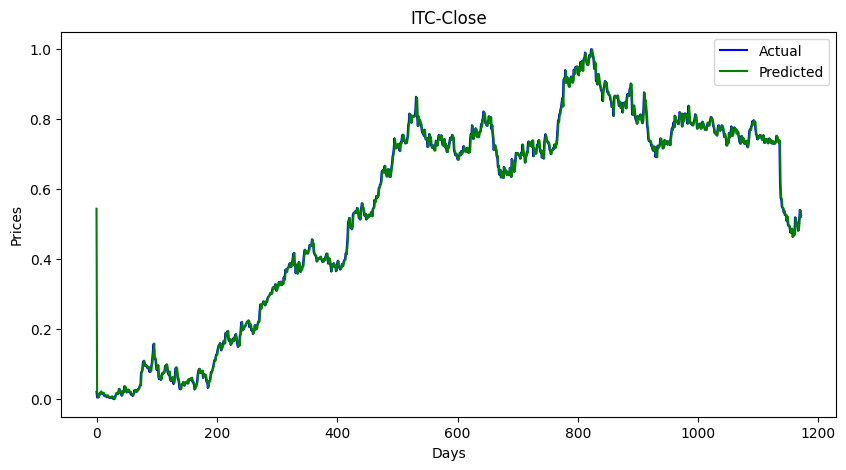

In [6]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","ITC-Close","Days","Prices")

In [7]:
len(data1)

1172

In [9]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(data1,["Close"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [10]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

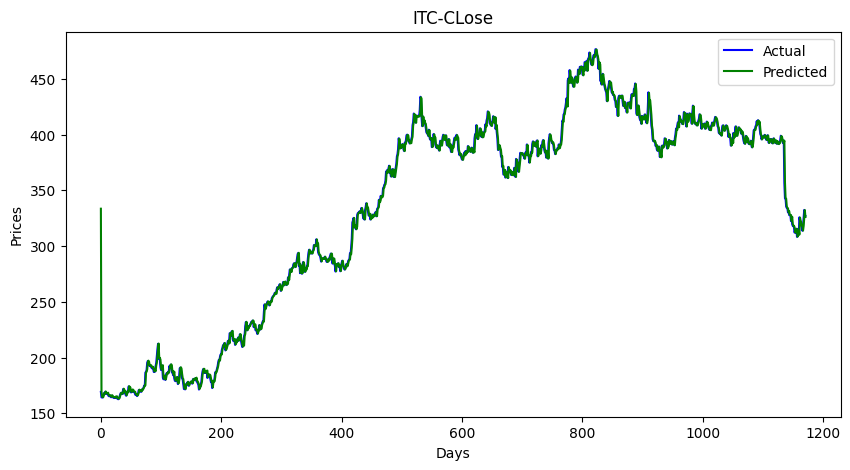

In [11]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","ITC-CLose","Days","Prices")

In [12]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 6.321766882560884
MAPE-Testset: 0.9887483827491121


In [13]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [14]:
forecast

array([0.52349615, 0.52354609, 0.52359592, 0.52364563])

In [15]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [16]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [17]:
forecast_stock_price_test_oriF

,Closefore
0,326.999538
1,327.015217
2,327.030859
3,327.046464
